# Kronos vs classical baselines — hourly volatility, 1-session horizon

**Dev set:** 30 US large-caps, 378 sessions (2024-07 → 2025-12), 11,340 forecasts,
fully out of sample (Kronos pretraining ends ~2024-06). Target: next session's
intraday realized vol (Garman–Klass). All baselines walk-forward.

The probe (8 names, pooled Spearman, no proper HAR) *overstated* Kronos. With
real baselines and hypothesis tests the picture is soberer — and more useful.


In [1]:
import os
if "src" not in os.listdir("."):
    os.chdir("..")

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.evaluate import assemble, vol_scorecard, dm_vs, incremental_r2, mcs, calibration, by_cut
from src.metrics import qlike
p = assemble("hourly", 1)
p = p[~p.in_lockbox].copy()
MODELS = ["har","kronos_recal","ewma94","rolling22","kronos","rw","gjr","garch"]
len(p), p.ticker.nunique(), p.origin.min().date(), p.origin.max().date()

/Users/isaac/Desktop/foundation_model_desk/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(11340, 30, datetime.date(2024, 7, 1), datetime.date(2025, 12, 31))

## 1 · Scorecard — HAR-RV wins, Kronos ≈ EWMA

In [3]:
sc = vol_scorecard(p, MODELS); sc.round(4)

,n,QLIKE,RMSE_logRV,MZ_slope,MZ_r2,bias
har,11340.0,0.2265,0.2877,0.9700,0.5850,-0.0009
kronos_recal,11340.0,0.2453,0.3044,0.9366,0.5362,-0.0005
ewma94,11340.0,0.2510,0.3449,0.8731,0.4760,0.0010
rolling22,11340.0,0.2605,0.3497,0.8214,0.4568,0.0009
kronos,11340.0,0.2617,0.3295,0.8126,0.5024,0.0005
rw,11340.0,0.2649,0.3293,0.7305,0.5253,0.0000
gjr,11340.0,0.3163,0.4435,0.7111,0.4526,0.0043
garch,11340.0,0.3268,0.4508,0.7192,0.4429,0.0044


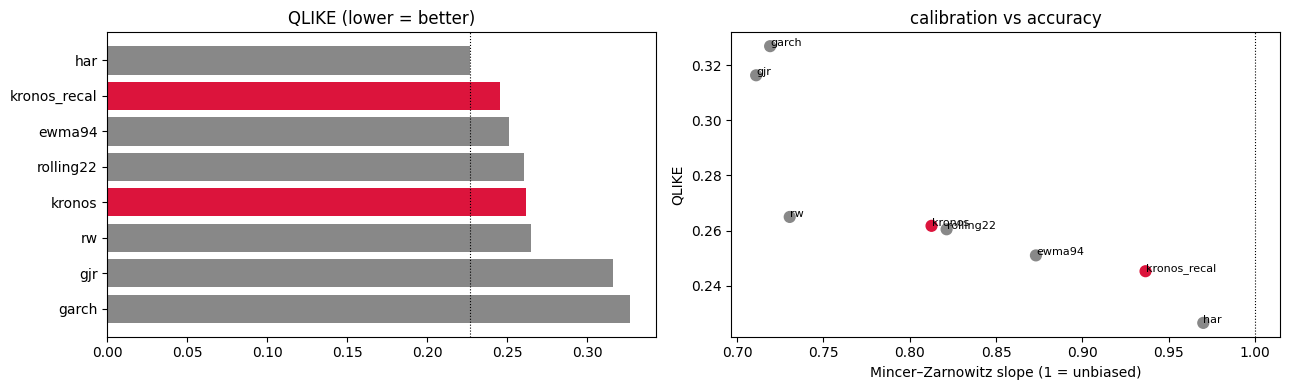

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
o = sc.sort_values("QLIKE")
c = ["crimson" if "kronos" in m else "#888" for m in o.index]
ax[0].barh(range(len(o)), o["QLIKE"], color=c); ax[0].set_yticks(range(len(o))); ax[0].set_yticklabels(o.index)
ax[0].invert_yaxis(); ax[0].set_title("QLIKE (lower = better)"); ax[0].axvline(o["QLIKE"].min(), ls=":", c="k", lw=.8)
ax[1].scatter(sc["MZ_slope"], sc["QLIKE"], c=c, s=60)
for m in sc.index: ax[1].annotate(m, (sc.loc[m,"MZ_slope"], sc.loc[m,"QLIKE"]), fontsize=8)
ax[1].axvline(1.0, ls=":", c="k", lw=.8); ax[1].set_xlabel("Mincer–Zarnowitz slope (1 = unbiased)"); ax[1].set_ylabel("QLIKE")
ax[1].set_title("calibration vs accuracy"); plt.tight_layout(); plt.show()

## 2 · Diebold–Mariano & the Model Confidence Set

In [5]:
print(dm_vs(p, ref="ewma94", models=[m for m in MODELS if m!="ewma94"]).round(4).to_string())
print()
print("Model Confidence Set (QLIKE, 90%):", mcs(p, MODELS))

                  n mean_loss_diff    DM_stat   p_value             verdict
har           11340      -0.024461  -5.984666       0.0  better than ewma94
kronos_recal  11340      -0.005736  -1.050271  0.293594                 tie
rolling22     11340       0.009464   4.766168  0.000002   worse than ewma94
kronos        11340       0.010712   0.676992  0.498411                 tie
rw            11340       0.013932   1.725027  0.084523   worse than ewma94
gjr           11340       0.065268   8.688415       0.0   worse than ewma94
garch         11340       0.075817  11.304779       0.0   worse than ewma94



Model Confidence Set (QLIKE, 90%): {'included': ['har'], 'excluded': ['ewma94', 'garch', 'gjr', 'kronos', 'kronos_recal', 'rolling22', 'rw'], 'pvalues': {'garch': 0.0, 'gjr': 0.0, 'rw': 0.0, 'rolling22': 0.0, 'ewma94': 0.0, 'kronos_recal': 0.004, 'kronos': 0.033, 'har': 1.0}}


HAR-RV is the **sole** member of the 90% MCS — every other model, Kronos
included, is statistically excluded as inferior. Raw Kronos vs EWMA is a
Diebold–Mariano tie.

## 3 · The one place Kronos wins — incremental information

In [6]:
rows = []
for signal in ["kronos","kronos_recal"]:
    for over in ["ewma94","har"]:
        r = incremental_r2(p, add=signal, base=over)
        rows.append({"signal":signal,"over":over,"R2_base":r[f"r2_{over}"],
                     "gain":r["gain"],"ci_lo":r["gain_ci95"][0],"ci_hi":r["gain_ci95"][1]})
inc = pd.DataFrame(rows); inc.round(4)

,signal,over,R2_base,gain,ci_lo,ci_hi
0,kronos,ewma94,0.476,0.0647,0.0581,0.0716
1,kronos,har,0.585,0.0125,0.0099,0.0153
2,kronos_recal,ewma94,0.476,0.0691,0.0623,0.0760
3,kronos_recal,har,0.585,0.0091,0.0070,0.0115


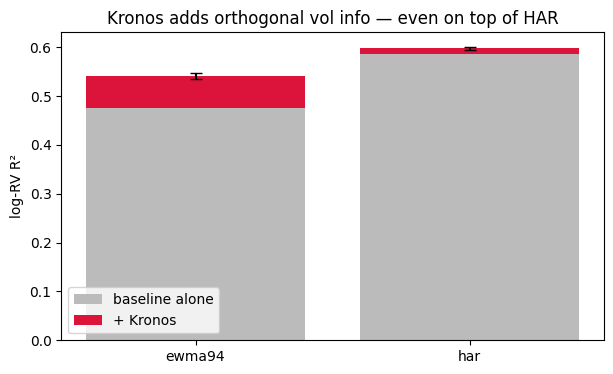

      signal   over  R2_base   gain  ci_lo  ci_hi
      kronos ewma94    0.476 0.0647 0.0581 0.0716
      kronos    har    0.585 0.0125 0.0099 0.0153
kronos_recal ewma94    0.476 0.0691 0.0623 0.0760
kronos_recal    har    0.585 0.0091 0.0070 0.0115


In [7]:
sub = inc[inc["signal"] == "kronos"].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(sub))
ax.bar(x, sub["R2_base"], label="baseline alone", color="#bbb")
ax.bar(x, sub["gain"], bottom=sub["R2_base"], label="+ Kronos", color="crimson")
ax.errorbar(x, sub["R2_base"]+sub["gain"],
            yerr=[sub["gain"]-sub["ci_lo"], sub["ci_hi"]-sub["gain"]],
            fmt="none", ecolor="k", capsize=4)
ax.set_xticks(x); ax.set_xticklabels(list(sub["over"])); ax.set_ylabel("log-RV R²")
ax.set_title("Kronos adds orthogonal vol info — even on top of HAR"); ax.legend(); plt.show()
print(inc.round(4).to_string(index=False))

Kronos lifts log-RV R² by **+0.065 over EWMA** and **+0.013 over HAR**
(the best model) — small, but both bootstrap CIs cleanly exclude zero. It is not
a better forecaster; it sees ~1 R² point of volatility that price-history models
miss.

## 4 · Calibration — overconfident, recalibration half-fixes it

In [8]:
cal = calibration(p); cal

{'return_cov_90': 0.68,
 'return_cov_50': 0.334,
 'return_PIT': {'n': 11340,
  'ks_stat': 0.15294117647058825,
  'ks_p': 4.482566038164497e-232,
  'mean': 0.5491233530449217,
  'std': 0.3452434229429344},
 'return_CRPS': 0.011816459119075839,
 'rv_cov_90': 0.716,
 'rv_PIT': {'n': 11340,
  'ks_stat': 0.18301172320780165,
  'ks_p': 0.0,
  'mean': 0.3946000622471211,
  'std': 0.317992013005073}}

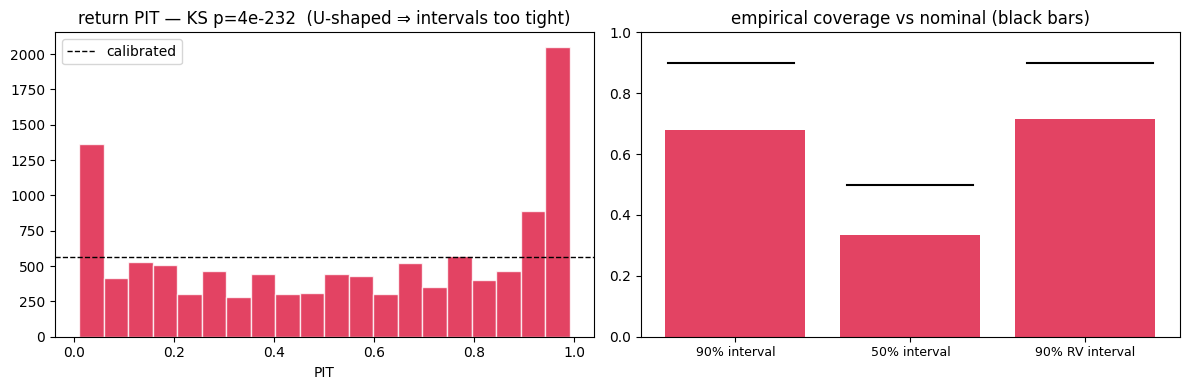

In [9]:
from src.metrics import pit_exact
dp = p.dropna(subset=["realised_ret"]); dp = dp[dp.ret_paths.notna()]
pit = pit_exact(dp["realised_ret"].to_numpy(), list(dp["ret_paths"]))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(pit, bins=20, color="crimson", alpha=.8, edgecolor="white")
ax[0].axhline(len(pit)/20, ls="--", c="k", lw=1, label="calibrated")
ax[0].set_title(f"return PIT — KS p={cal['return_PIT']['ks_p']:.0e}  (U-shaped ⇒ intervals too tight)")
ax[0].set_xlabel("PIT"); ax[0].legend()
covs = {"90% interval": (cal["return_cov_90"], .90), "50% interval": (cal["return_cov_50"], .50),
        "90% RV interval": (cal.get("rv_cov_90", np.nan), .90)}
ax[1].bar(range(len(covs)), [v[0] for v in covs.values()], color="crimson", alpha=.8)
for i,(k,v) in enumerate(covs.items()): ax[1].axhline(v[1], xmin=i/len(covs)+.05, xmax=(i+1)/len(covs)-.05, c="k")
ax[1].set_xticks(range(len(covs))); ax[1].set_xticklabels(covs.keys(), fontsize=9)
ax[1].set_title("empirical coverage vs nominal (black bars)"); ax[1].set_ylim(0,1); plt.tight_layout(); plt.show()

## 5 · By regime — Kronos is *not* better when it's turbulent

In [10]:
reg = by_cut(p, "vol_q", MODELS); reg.round(4)

,har,kronos_recal,ewma94,rolling22,kronos,rw,gjr,garch,n
calm,0.1151,0.1489,0.2392,0.2212,0.2120,0.1439,0.3700,0.3894,2835.0
low,0.0726,0.0802,0.1242,0.1278,0.1263,0.1495,0.2345,0.2448,2835.0
elevated,0.1292,0.1323,0.1293,0.1423,0.1629,0.2171,0.2247,0.2265,2835.0
turbulent,0.5892,0.6197,0.5114,0.5506,0.5457,0.5493,0.4359,0.4466,2835.0


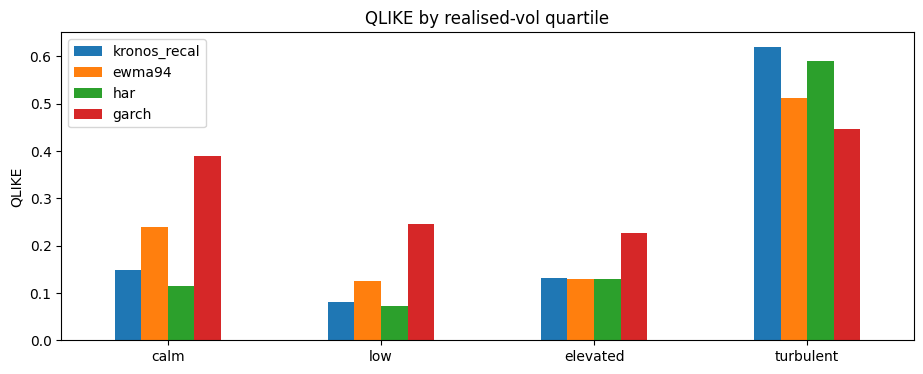

In [11]:
r = reg[["kronos_recal","har","ewma94","garch"]].drop(columns=[]).iloc[:, :]
r = reg.loc[["calm","low","elevated","turbulent"], ["kronos_recal","ewma94","har","garch"]]
r.plot.bar(figsize=(11,4)); plt.ylabel("QLIKE"); plt.title("QLIKE by realised-vol quartile"); plt.xticks(rotation=0); plt.show()

The probe's "edge concentrates in turbulent regimes" was an artefact of
pooled cross-name Spearman. On QLIKE, Kronos is **worst** in the turbulent
quartile; GARCH (mean-reverting) wins there.

## 6 · By sector — the actual signal: Kronos helps where vol is *flow-driven*

In [12]:
sec = by_cut(p, "sector", MODELS)
sec["kronos_edge_vs_ewma"] = sec["ewma94"] - sec["kronos_recal"]   # positive = Kronos better
sec = sec.sort_values("kronos_edge_vs_ewma", ascending=False)
sec[["n","kronos_recal","ewma94","har","kronos_edge_vs_ewma"]].round(4)

,n,kronos_recal,ewma94,har,kronos_edge_vs_ewma
Tech,2268.0,0.2300,0.2624,0.2096,0.0323
Fin,1512.0,0.2654,0.2919,0.2485,0.0266
ConsDisc,1512.0,0.2095,0.2253,0.2019,0.0158
Comm,1134.0,0.2288,0.2442,0.2242,0.0154
Indu,756.0,0.2602,0.2754,0.2619,0.0151
Energy,756.0,0.1989,0.2127,0.2006,0.0139
ConsStap,1134.0,0.2239,0.2254,0.2108,0.0015
Materials,378.0,0.2491,0.2224,0.1861,-0.0268
Utilities,378.0,0.3013,0.2476,0.2333,-0.0537
Health,1512.0,0.3129,0.2580,0.2720,-0.0548


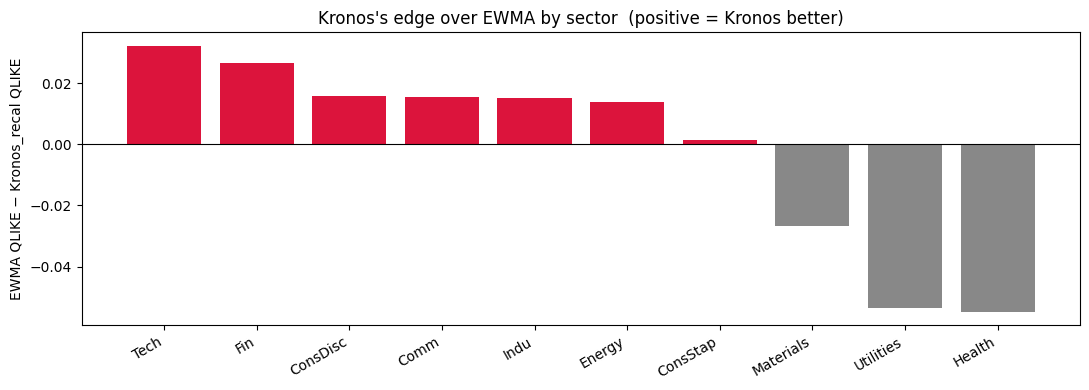

In [13]:
fig, ax = plt.subplots(figsize=(11,4))
c = ["crimson" if v>0 else "#888" for v in sec["kronos_edge_vs_ewma"]]
ax.bar(sec.index, sec["kronos_edge_vs_ewma"], color=c)
ax.axhline(0, c="k", lw=.8); ax.set_ylabel("EWMA QLIKE − Kronos_recal QLIKE")
ax.set_title("Kronos's edge over EWMA by sector  (positive = Kronos better)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

**Kronos beats EWMA in Tech, Comm, Consumer Discretionary — and loses in
Health, Utilities, Materials.**

The pattern is *what drives short-horizon vol in each sector*:

- **Tech / growth / consumer disc:** vol is **flow-driven** — momentum, gap
  continuation, options-gamma, retail. It shows up in candle shapes and volume,
  which is exactly what Kronos reads.
- **Health, utilities, materials:** vol is **event-driven** (FDA rulings,
  litigation, guidance cuts, drug-pricing politics, rate moves) or just sleepy.
  Discrete catalysts are invisible to a price-only model — hence the big UNH /
  LLY misses in the Health bucket.

Kronos does best exactly where catalysts matter least and price structure
matters most. That is the same limitation seen in the probe (the TSLA-earnings /
DeepSeek misses), viewed cross-sectionally.

## 7 · One name, over time

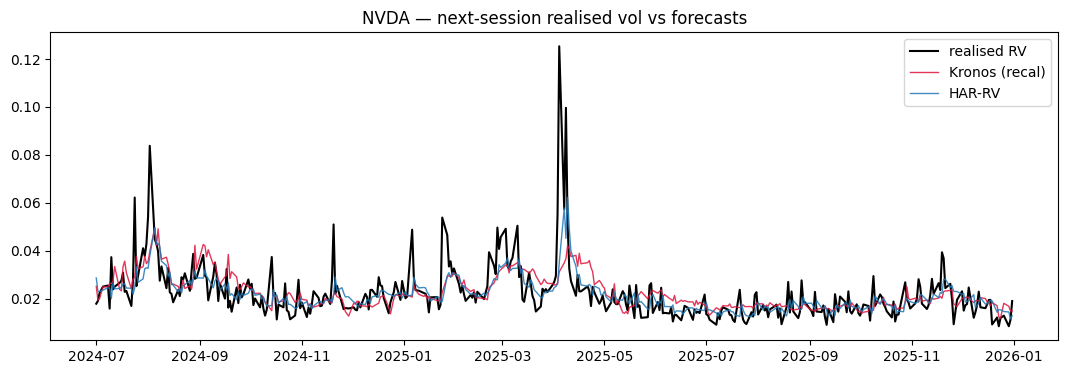

In [14]:
tk = "NVDA"
g = p[p.ticker==tk].sort_values("origin")
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(g.origin, g.realised, c="k", lw=1.5, label="realised RV")
ax.plot(g.origin, g.kronos_recal, c="crimson", lw=1, alpha=.85, label="Kronos (recal)")
ax.plot(g.origin, g.har, c="tab:blue", lw=1, alpha=.85, label="HAR-RV")
ax.set_title(f"{tk} — next-session realised vol vs forecasts"); ax.legend(); plt.show()

---
## What this establishes

1. **Kronos-small is not a good standalone equity vol forecaster.** HAR-RV beats
   it on QLIKE, RMSE, calibration, and is the sole Model Confidence Set member.
   Raw Kronos ≈ EWMA; recalibration lifts it just past EWMA, still short of HAR.
2. **It carries a small, robust slice of orthogonal information** — +0.013 log-RV
   R² even on top of HAR (CI [0.010, 0.015]).
3. **Its intervals are overconfident** — 68% coverage for a nominal 90% — and an
   expanding-window affine recalibration only half-closes the gap.
4. **The edge is where vol is flow-driven, not news-driven** — Tech/Comm/ConsDisc,
   not Health/Utilities/Materials. Consistent with a price-only model being blind
   to discrete catalysts.

## Still open
- GARCH/GJR baselines are fit on close-to-close returns (target is intraday) —
  unfair, needs an intraday-returns refit. Won't change the HAR verdict.
- Lockbox (2026-01 → 2026-08) untouched.
- L=250 / S=50 sensitivity checks.
- Daily-horizon study.
